In [2]:
import sys

# Checking if colab or local
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    path = '/content/drive/MyDrive/Grokking Machine Learning/Bootcamp Materials/04- Python Deep Learning/W21/P1_Sentiment Analysis/tweets.csv'
else:
    path = 'tweets.csv'


# Data Description

**This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the Twitter API. The tweets have been annotated (0 = negative, 2 = neutral, 4 = positive) and they can be used to detect sentiment. It contains the following 6 fields:**

- `target`: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
- `ids`: The ID of the tweet (2087)
- `date`: the date of the tweet (Sat May 16 23:58:44 UTC 2009)
- `flag`: The query (lyx). If there is no query, then this value is NO_QUERY.
- `user`: the user that tweeted (robotickilldozr)
- `text`: the text of the tweet (Lyx is cool)

The official link regarding the dataset with resources about how it was generated is [here](official_link).

The official paper detailing the approach is [here](official_paper).

According to the creators of the dataset:

"Our approach was unique because our training data was automatically created, as opposed to having humans manually annotate tweets. In our approach, we assume that any tweet with positive emoticons, like :), was positive, and tweets with negative emoticons, like :(, were negative. We used the Twitter Search API to collect these tweets by using keyword search."

Citation: Go, A., Bhayani, R. and Huang, L., 2009. [Twitter sentiment classification using distant supervision](citation_link). CS224N Project Report, Stanford, 1(2009), p.12.


# Read Dataset

In [3]:
import pandas as pd

data = pd.read_csv(path, encoding = "ISO-8859-1", header=None)
data.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df = data[['target', 'text']]
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [6]:
df.target.value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [7]:
df.loc[:, 'target'] = df.target.replace(4, 1)
df.target.value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

# Text Preprocessing

In [8]:
import nltk
nltk.download('stopwords', quiet=True)

True

In [9]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
import re

to_remove = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
stopwords_ = stopwords.words('english')
stemmer = SnowballStemmer("english")

def preprocess_text(text, stem=False):
    # Remove link,user and special characters
    text = re.sub(to_remove, ' ', text.lower()).strip()
    tokens = text.split()
    # Remove stop words
    tokens = [token for token in tokens if token not in stopwords_]
    # Stemming the tokens
    if stem:
        tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(tokens)

In [10]:
df.text[10]

"spring break in plain city... it's snowing "

In [11]:
preprocess_text(df.text[10])

'spring break plain city snowing'

In [12]:
preprocess_text(df.text[10], stem=True)

'spring break plain citi snow'

In [13]:
%%time
df['processed_text'] = df.text.apply(lambda x: preprocess_text(x, stem=True))

CPU times: total: 3min
Wall time: 3min 1s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [14]:
df.head()

,target,text,processed_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save 50 rest go bound
3,0,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,"@nationwideclass no, it's not behaving at all....",behav mad see


# Split data

In [15]:
X = df.processed_text
y = df.target

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1280000,) (320000,) (1280000,) (320000,)


In [17]:
X_train.head()

1374558    ya quot like palm pre touchston charger readyn...
1389115                felt earthquak afternoon seem epicent
1137831                               ruffl shirt like likey
790714     pretti bad night crappi morn fml buttfac didnt...
1117911                                      yeah clear view
Name: processed_text, dtype: object

# Word Embeddings (Feature Extraction)

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create the tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

# Get the vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary size:', vocab_size)

# Set the maximum sequence length
max_length = max([len(seq) for seq in X_train])
print('Maximum sequence length:', max_length)

Vocabulary size: 248736
Maximum sequence length: 50


In [19]:
import numpy as np
lengths = [len(seq) for seq in X_train]
max_length2 = int(np.percentile(lengths, 95))  
max_length2

15

In [ ]:
X_train[0]

[183, 8, 6, 1965, 1126, 33195, 2107, 56889, 88, 147, 4, 636, 137, 19273]

In [ ]:
# Convert text to sequences and pad sequences
X_train_sequences = pad_sequences(X_train, padding='post', maxlen=max_length)
X_test_sequences = pad_sequences(X_test, padding='post', maxlen=max_length)

# Print tokenized sequences
print('X_train_sequences:', X_train_sequences.shape)
print('X_test_sequences:', X_test_sequences.shape)

X_train_sequences: (1280000, 50)
X_test_sequences: (320000, 50)


In [ ]:
X_train_sequences[0]

array([  183,     8,     6,  1965,  1126, 33195,  2107, 56889,    88,
         147,     4,   636,   137, 19273,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0])

# Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Define the neural network model with input shape in Flatten layer
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=max_length, input_length=max_length),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 50)            12436800  
                                                                 
 flatten (Flatten)           (None, 2500)              0         
                                                                 
 dense (Dense)               (None, 32)                80032     
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 12,516,865
Trainable params: 12,516,865
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# checkpoint and early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
filepath = 'model.h5'
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1)
callbacks = [checkpoint, early_stopping]

In [ ]:
# Train the model
model.fit(X_train_sequences, y_train, validation_split=0.1, epochs=50, batch_size=32, verbose=1, callbacks=callbacks)

Epoch 1/50
36000/36000 [==============================] - ETA: 0s - loss: 0.4757 - accuracy: 0.7705
Epoch 1: val_accuracy improved from -inf to 0.77697, saving model to model.h5
36000/36000 [==============================] - 418s 12ms/step - loss: 0.4757 - accuracy: 0.7705 - val_loss: 0.4667 - val_accuracy: 0.7770
Epoch 2/50
35996/36000 [============================>.] - ETA: 0s - loss: 0.4338 - accuracy: 0.7974
Epoch 2: val_accuracy improved from 0.77697 to 0.77812, saving model to model.h5
36000/36000 [==============================] - 401s 11ms/step - loss: 0.4338 - accuracy: 0.7974 - val_loss: 0.4665 - val_accuracy: 0.7781
Epoch 3/50
35998/36000 [============================>.] - ETA: 0s - loss: 0.3915 - accuracy: 0.8217
Epoch 3: val_accuracy did not improve from 0.77812
36000/36000 [==============================] - 398s 11ms/step - loss: 0.3915 - accuracy: 0.8217 - val_loss: 0.4861 - val_accuracy: 0.7729
Epoch 4/50
35996/36000 [============================>.] - ETA: 0s - loss: 0.

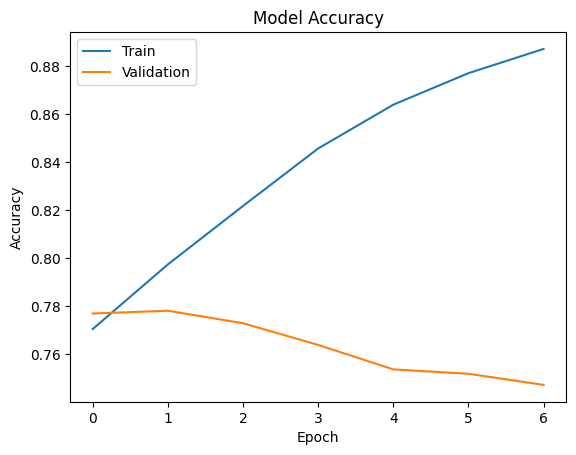

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

> Overfitting

In [ ]:
from tensorflow.keras.layers import Dropout

model_reg = Sequential([
    Embedding(input_dim=vocab_size, output_dim=max_length, input_length=max_length),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.35),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model_reg.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 50, 50)            12436800  
                                                                 
 flatten_1 (Flatten)         (None, 2500)              0         
                                                                 
 dense_2 (Dense)             (None, 32)                80032     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 12,516,865
Trainable params: 12,516,865
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_reg.fit(X_train_sequences, y_train, validation_split=0.1, epochs=50, batch_size=32, verbose=1, callbacks=callbacks)

Epoch 1/50
35997/36000 [============================>.] - ETA: 0s - loss: 0.4862 - accuracy: 0.7667
Epoch 1: val_accuracy did not improve from 0.77812
36000/36000 [==============================] - 408s 11ms/step - loss: 0.4862 - accuracy: 0.7667 - val_loss: 0.4686 - val_accuracy: 0.7770
Epoch 2/50
35998/36000 [============================>.] - ETA: 0s - loss: 0.4489 - accuracy: 0.7914
Epoch 2: val_accuracy did not improve from 0.77812
36000/36000 [==============================] - 403s 11ms/step - loss: 0.4489 - accuracy: 0.7914 - val_loss: 0.4676 - val_accuracy: 0.7768
Epoch 3/50
36000/36000 [==============================] - ETA: 0s - loss: 0.4169 - accuracy: 0.8081
Epoch 3: val_accuracy did not improve from 0.77812
36000/36000 [==============================] - 398s 11ms/step - loss: 0.4169 - accuracy: 0.8081 - val_loss: 0.4797 - val_accuracy: 0.7740
Epoch 4/50
35997/36000 [============================>.] - ETA: 0s - loss: 0.3834 - accuracy: 0.8251
Epoch 4: val_accuracy did not imp

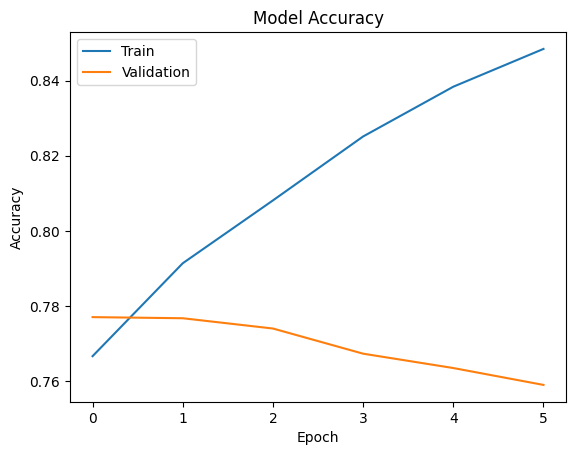

In [ ]:
plt.plot(model_reg.history.history['accuracy'])
plt.plot(model_reg.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model
loss, accuracy = model_reg.evaluate(X_test_sequences, y_test)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

10000/10000 [==============================] - 19s 2ms/step - loss: 0.5676 - accuracy: 0.7606
Test loss: 0.5676394701004028
Test accuracy: 0.7605937719345093


10000/10000 [==============================] - 11s 1ms/step
              precision    recall  f1-score   support

           0       0.74      0.81      0.77    159494
           1       0.79      0.72      0.75    160506

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000



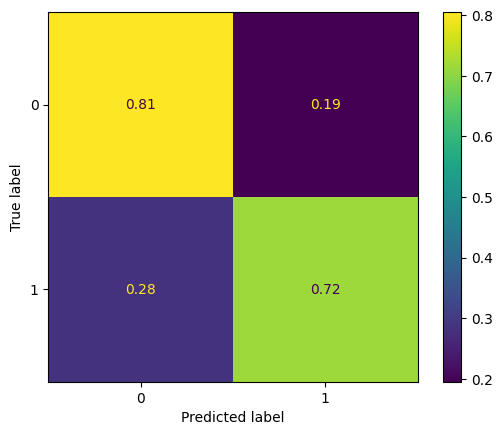

In [ ]:
# Classification report
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = model_reg.predict(X_test_sequences)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true')